In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI/week2/wine.csv')

df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [ ]:
X=df.drop('Wine',axis=1)
y=df['Wine']

In [ ]:
scaler = StandardScaler() # 각 특성(열)의 평균을 0, 표준편차를 1로 맞추기 위한 객체 생성
X = scaler.fit_transform(X) # 그 값을 이용해 데이터를 표준화(transform)

In [ ]:
# y의 범주형 값을 원-핫 인코딩(One-Hot Encoding)으로 변환한 뒤
# 넘파이 배열 형태로 저장
Y = pd.get_dummies(y).values

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((142, 13), (142, 3), (36, 13), (36, 3))

In [ ]:
# Sequential 방식으로 딥러닝 분류 모델 생성
model = models.Sequential([
    # 입력층 + 첫 번째 은닉층
    # 뉴런 64개, 활성화 함수는 ReLU
    # input_shape=(X.shape[1],) 는 입력 특성 개수를 의미
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),

    # 드롭아웃 층
    # 학습 중 30%의 뉴런을 무작위로 비활성화하여 과적합 방지
    layers.Dropout(0.3),

    # 두 번째 은닉층
    # 뉴런 32개, 활성화 함수는 ReLU
    layers.Dense(32, activation="relu"),

    # 출력층
    # 뉴런 3개 = 클래스가 3개라는 뜻
    # softmax를 사용하여 각 클래스에 대한 확률 출력
    layers.Dense(3, activation="softmax")   # 클래스 수 맞춤
])

# 모델 학습 방식 설정
model.compile(
    optimizer="adam",                  # 가중치 최적화 방법
    loss="categorical_crossentropy",   # 원-핫 인코딩된 다중분류용 손실 함수
    metrics=["accuracy"]               # 성능 평가 지표로 정확도 사용
)

# 모델 학습
history = model.fit(
    X_train, y_train,          # 학습 데이터
    validation_split=0.2,      # 학습 데이터의 20%를 검증용으로 사용
    epochs=50,                 # 전체 데이터를 50번 반복 학습
    batch_size=16,             # 한 번에 16개씩 묶어서 학습
    verbose=1                  # 학습 과정을 출력
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3186 - loss: 1.1493 - val_accuracy: 0.3448 - val_loss: 0.9940
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6018 - loss: 0.9301 - val_accuracy: 0.7586 - val_loss: 0.8214
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7345 - loss: 0.7819 - val_accuracy: 0.9655 - val_loss: 0.6761
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7876 - loss: 0.6724 - val_accuracy: 0.9655 - val_loss: 0.5513
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9115 - loss: 0.5597 - val_accuracy: 1.0000 - val_loss: 0.4430
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8850 - loss: 0.5003 - val_accuracy: 1.0000 - val_loss: 0.3558
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9115 - loss: 0.4030 - val_accuracy: 1.0000 - val_loss: 0.2850
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9292 - loss: 0.3364 - val_accuracy: 1.0000 - val_loss: 0.2293
Epoch 9/50


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


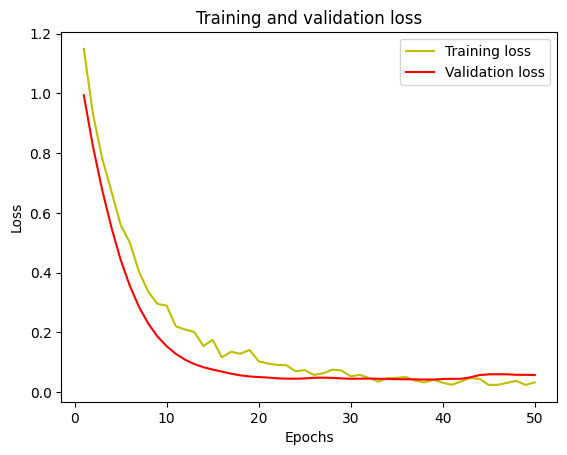

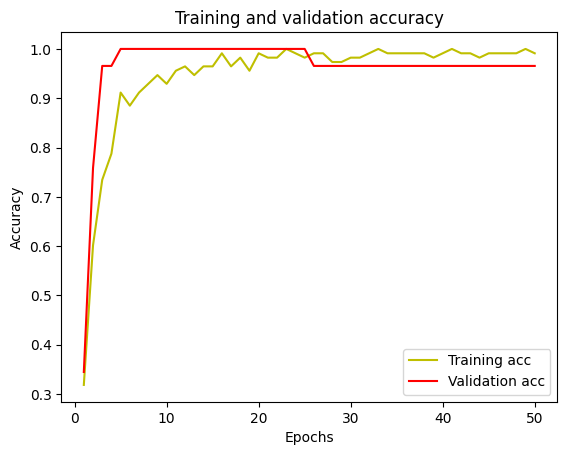

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00         6

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]


In [ ]:

y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))